In [1]:
from google.colab import files

uploaded = files.upload()

Saving eda_analysis_workbook_cleaned.xlsx to eda_analysis_workbook_cleaned.xlsx


In [2]:
!ls -la /content

total 64
drwxr-xr-x 1 root root  4096 Jul 21 16:06 .
drwxr-xr-x 1 root root  4096 Jul 21 15:58 ..
drwxr-xr-x 4 root root  4096 Jun  4 13:32 .config
-rw-r--r-- 1 root root 48878 Jul 21 16:06 eda_analysis_workbook_cleaned.xlsx
drwxr-xr-x 1 root root  4096 Jun  4 13:32 sample_data


In [3]:
import pandas as pd


In [4]:
df = pd.read_excel(
    "eda_analysis_workbook_cleaned.xlsx",
    header=0
)

In [5]:
#checking
df.head()

,Author,Source,Country,Gender,Type,Year,Title,abstract,Concealment,Shame,...,Masculinity,Help Seeking,Notes,Reported Prevalence,Measurement Tool,ED Type,Stigma,age group,sample size,Region
0,Murray,PubMed,Australia,Male,Critical Review,2017,The Enigma of Male Eating Disorders: A Critica...,"Historically, male presentations of eating dis...",1,1,...,1,1,Male EDs are underdiagnosed due to stigma and ...,NaN,Review,Mixed,1,Adolescents & Adults,NaN,Oceania
1,Martin S. Lehe,Journal of Eating Disorders,Germany,Male,Cross-sectional,2024,Invisible walls? Stigma-related perceptions ar...,Background Eating disorders (EDs) are increasi...,1,1,...,1,1,Stigma significantly reduced help-seeking inte...,NaN,EDE-Q; MDDI; DOS; EDY-Q; SOCQ-ED,Mixed,1,Adults,132,Europe
2,Lehe,PubMed,Germany,Male,Cross-sectional,2025,Boys don’t try? Gendered stigma specifically r...,Background: Eating disorders (EDs) affect indi...,1,1,...,1,1,Gender-specific stigma discourages help-seekin...,NaN,EDE-Q; DOS; EDY-Q; MDDI; SOCQ-ED; Self-develop...,Mixed,1,Adults,491,Europe
3,Coopey,PubMed,United Kingdom,Male,Qualitative Evidence Synthesis (Meta-Ethnography),2022,The male elephant in the room: a qualitative e...,Men are believed to be underrepresented in eat...,1,1,...,1,1,"Masculinity, stigma, and societal expectations...",NaN,Meta-ethnography,NaN,1,Adults,89,Europe
4,Sangha,PubMed,Canada,Male,Scoping Review,2019,Eating Disorders in Males: How Primary Care Pr...,Eating disorders are complex and multifactoria...,1,1,...,1,1,"Masculinity, stigma, and lack of awareness cau...",NaN,Scoping Review,NaN,1,All Ages,15 studies,North America


In [6]:
#checking
df.shape

(50, 21)

In [7]:
#checking
df.columns

Index(['Author', 'Source', 'Country', 'Gender', 'Type', 'Year', 'Title',
       'abstract', 'Concealment', 'Shame', 'Family', 'Masculinity',
       'Help Seeking', 'Notes', 'Reported Prevalence', 'Measurement Tool',
       'ED Type', 'Stigma', 'age group', 'sample size', 'Region'],
      dtype='object')

In [8]:
#checking
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Author               50 non-null     object
 1   Source               50 non-null     object
 2   Country              50 non-null     object
 3   Gender               50 non-null     object
 4   Type                 50 non-null     object
 5   Year                 50 non-null     int64 
 6   Title                50 non-null     object
 7   abstract             50 non-null     object
 8   Concealment          50 non-null     int64 
 9   Shame                50 non-null     int64 
 10  Family               50 non-null     int64 
 11  Masculinity          50 non-null     int64 
 12  Help Seeking         50 non-null     int64 
 13  Notes                50 non-null     object
 14  Reported Prevalence  19 non-null     object
 15  Measurement Tool     50 non-null     object
 16  ED Type   

In [9]:
#checking if anything is missing
df.isnull().sum()

,0
Author,0
Source,0
Country,0
Gender,0
Type,0
Year,0
Title,0
abstract,0
Concealment,0
Shame,0


In [10]:
#save a cleaned copy of df to excel
df.to_excel("cleaned_dataset_final.xlsx", index = False)

In [11]:
#How many studies and variables are included?
df.shape

(50, 21)

In [12]:
#How has publication changed over time?
df["Year"].value_counts().sort_index()

,count
Year,
2005,2
2008,1
2014,2
2015,2
2017,3
2018,1
2019,2
2020,4
2021,3


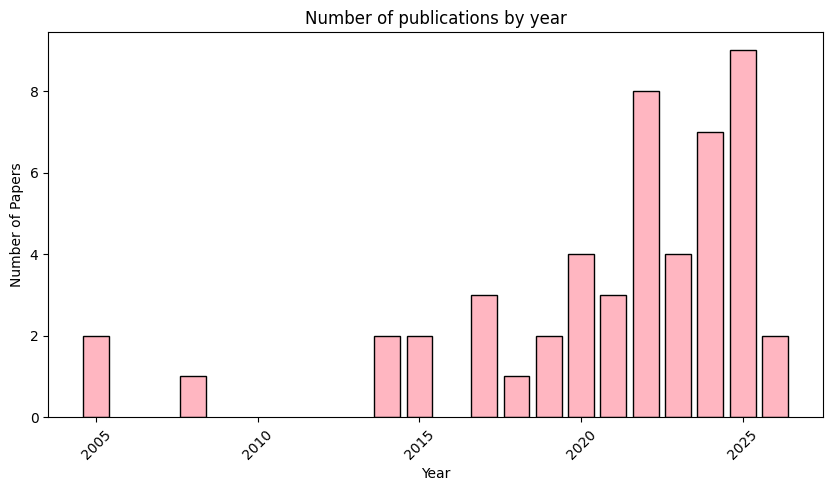

In [13]:
import matplotlib.pyplot as plt

#for publications by year, im doing the EDA from here on

year_counts = df["Year"].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(year_counts.index, year_counts.values, color = "lightpink",  edgecolor="black")
plt.title("Number of publications by year")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.xticks(rotation = 45)
plt.show()

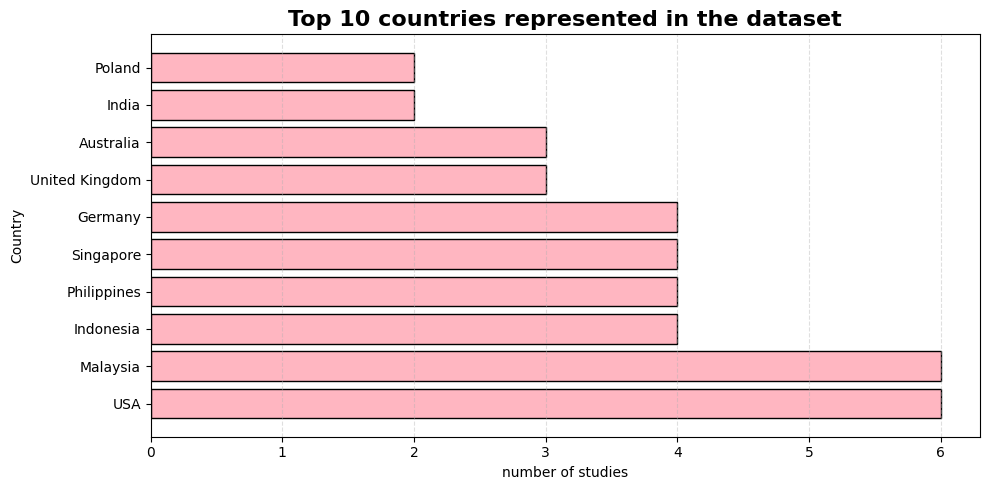

In [14]:
#study by country
import matplotlib.pyplot as plt
country_counts = df["Country"].value_counts().head(10)
plt.figure(figsize = (10,5))
plt.barh(country_counts.index, country_counts.values, color = "lightpink",  edgecolor="black")
plt.title("Top 10 countries represented in the dataset",
          fontsize = 16,
          fontweight = 'bold')

plt.xlabel("number of studies")
plt.ylabel("Country")

plt.grid(axis = 'x', linestyle = '--', alpha = 0.4)
plt.tight_layout()

plt.show()

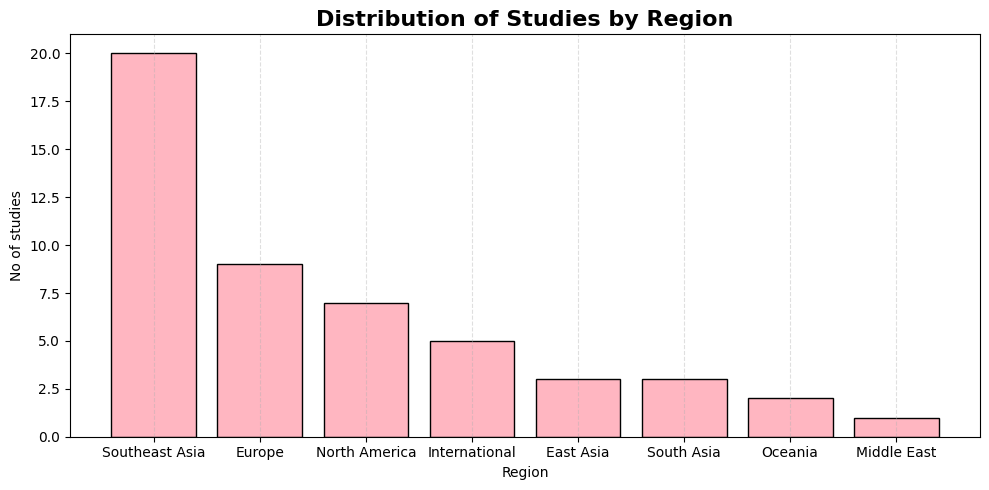

In [15]:
#region distribution
import matplotlib.pyplot as plt
region_counts = df["Region"].value_counts()
plt.figure(figsize = (10,5))
plt.bar(region_counts.index, region_counts.values, color = "lightpink",  edgecolor="black")
plt.title("Distribution of Studies by Region",
          fontsize = 16,
          fontweight = 'bold')

plt.xlabel("Region")
plt.ylabel("No of studies")

plt.grid(axis = 'x', linestyle = '--', alpha = 0.4)
plt.tight_layout()

plt.show()

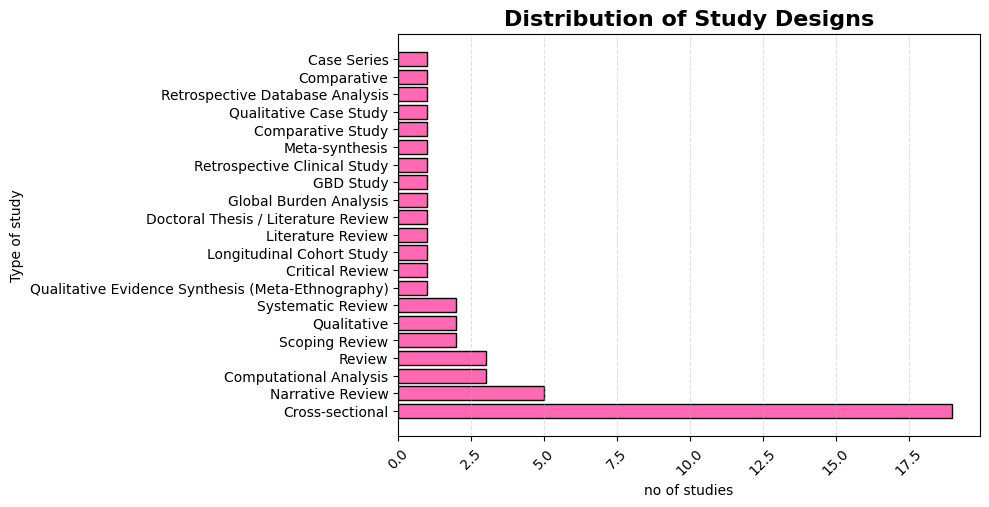

In [16]:
#study type distribution
import matplotlib.pyplot as plt
type_counts = df["Type"].value_counts()
plt.figure(figsize = (10,5))
plt.barh(type_counts.index, type_counts.values, color = "hotpink",  edgecolor="black")
plt.title("Distribution of Study Designs",
          fontsize = 16,
          fontweight = 'bold')

plt.xlabel("no of studies")
plt.ylabel("Type of study")

plt.grid(axis = 'x', linestyle = '--', alpha = 0.4)
plt.tight_layout()
plt.xticks(rotation = 45)
plt.show()

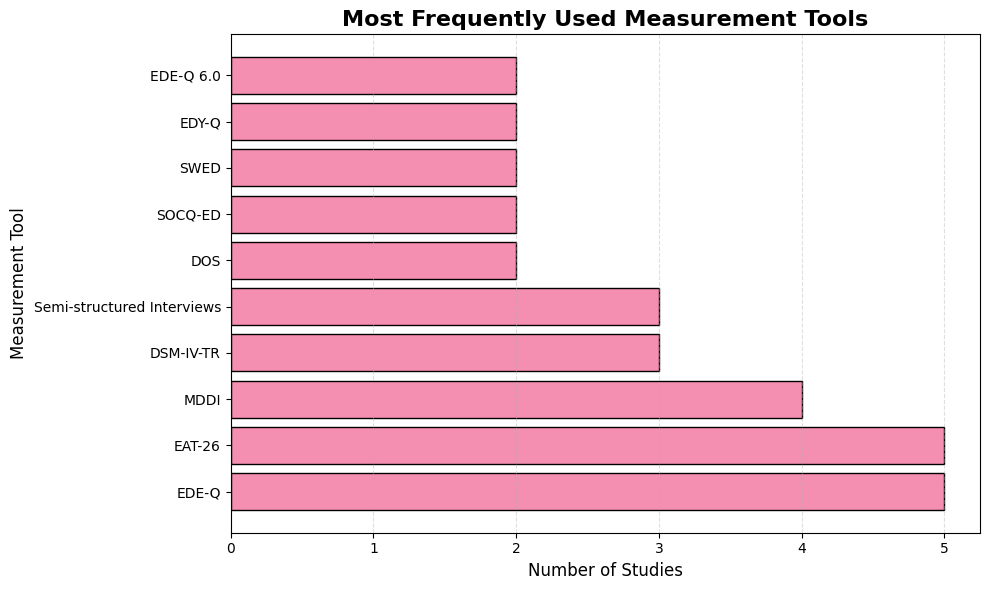

In [17]:
#measurement tools
# Distribution of Measurement Tools

import matplotlib.pyplot as plt

# Split multiple measurement tools into individual entries
tools = (
    df["Measurement Tool"]
    .str.split(";")
    .explode()
    .str.strip()
)

# Count frequency of each tool
tool_counts = tools.value_counts()

# Remove study designs that are not measurement tools
tool_counts = tool_counts.drop([
    "Review",
    "Narrative Review",
    "Literature Review",
    "Scoping Review"
], errors="ignore")

# Keep only the 10 most common tools
tool_counts = tool_counts.head(10)

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    tool_counts.index,
    tool_counts.values,
    color="#F48FB1",
    edgecolor="black"
)

plt.title(
    "Most Frequently Used Measurement Tools",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Studies", fontsize=12)
plt.ylabel("Measurement Tool", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()

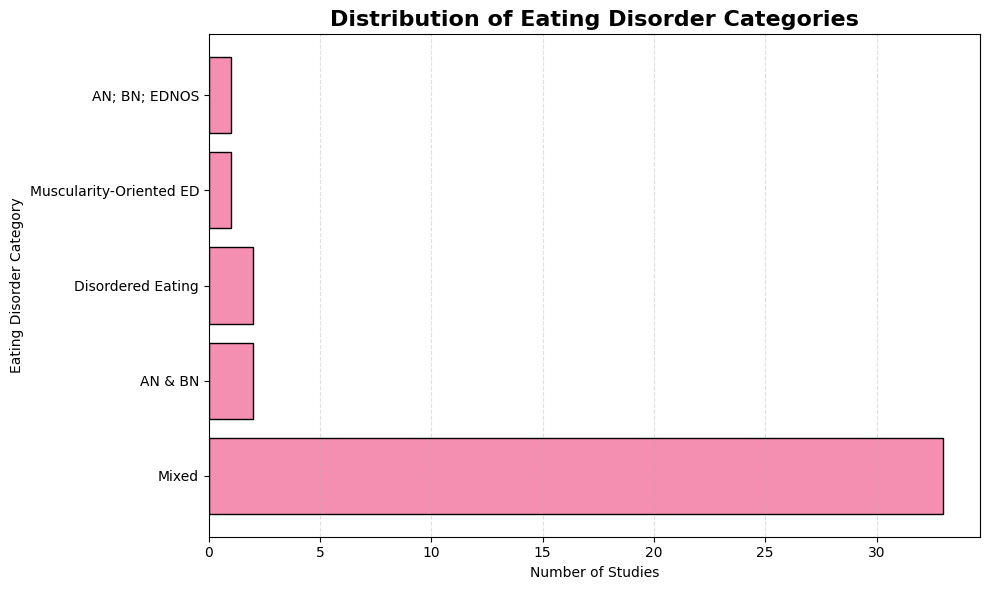

In [18]:
import matplotlib.pyplot as plt

ed_counts = df["ED Type"].value_counts()

plt.figure(figsize=(10,6))

bars = plt.barh(
    ed_counts.index,
    ed_counts.values,
    color="#F48FB1",
    edgecolor="black"
)

plt.title(
    "Distribution of Eating Disorder Categories",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Studies")
plt.ylabel("Eating Disorder Category")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [19]:
themes = [
    "Concealment",
    "Shame",
    "Family",
    "Masculinity",
    "Help Seeking",
    "Stigma"
]

theme_counts = df[themes].sum()

theme_counts

,0
Concealment,30
Shame,44
Family,15
Masculinity,32
Help Seeking,31
Stigma,32


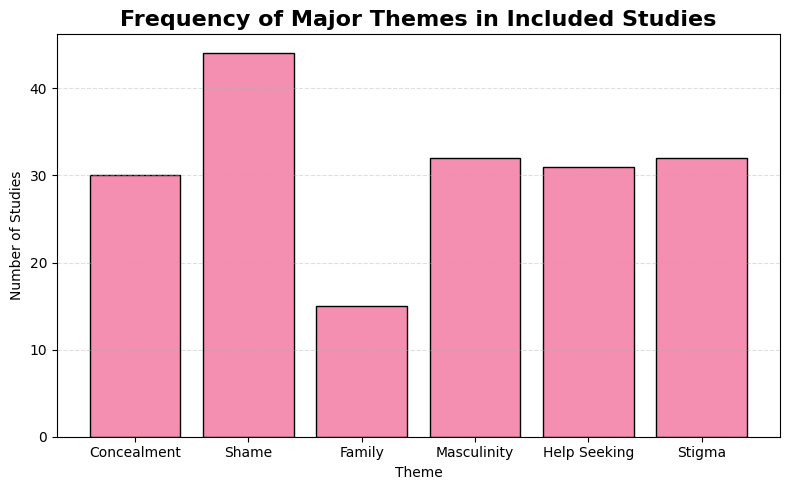

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    theme_counts.index,
    theme_counts.values,
    color="#F48FB1",
    edgecolor="black"
)

plt.title(
    "Frequency of Major Themes in Included Studies",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Theme")
plt.ylabel("Number of Studies")

plt.grid(axis="y", linestyle="--", alpha=0.4)


plt.tight_layout()
plt.show()

In [21]:
themes = [
    "Concealment",
    "Shame",
    "Family",
    "Masculinity",
    "Help Seeking",
    "Stigma"
]

corr = df[themes].corr()

corr

,Concealment,Shame,Family,Masculinity,Help Seeking,Stigma
Concealment,1.000000,0.201008,0.534522,0.238145,0.874722,0.833507
Shame,0.201008,1.000000,0.107443,0.107705,0.218092,0.235925
Family,0.534522,0.107443,1.000000,0.127294,0.512516,0.400066
Masculinity,0.238145,0.107705,0.127294,1.000000,0.271262,0.218750
Help Seeking,0.874722,0.218092,0.512516,0.271262,1.000000,0.786315
Stigma,0.833507,0.235925,0.400066,0.218750,0.786315,1.000000


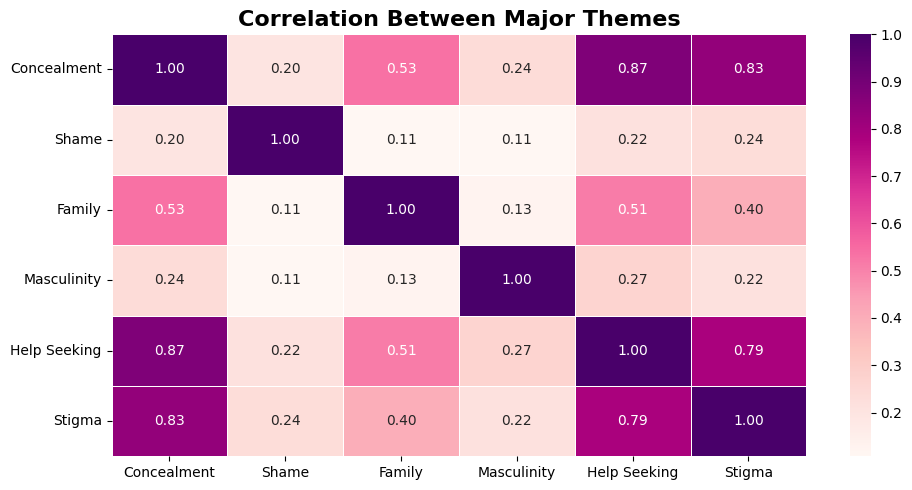

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))

sns.heatmap(
    corr,
    annot = True,
    cmap = "RdPu",
    linewidth = 0.5,
    fmt = ".2f"
)

plt.title(
    "Correlation Between Major Themes",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [23]:
# Select papers discussing concealment

concealment_df = df[df["Concealment"] == 1]

print(concealment_df.shape)

(30, 21)


In [24]:
#count themes in concealment papers

themes = [
    "Stigma",
    "Shame",
    "Family",
    "Masculinity",
    "Help Seeking"
]

for theme in themes:
    count = concealment_df[theme].sum()
    percentage = (count / len(concealment_df)) * 100

    print(f"{theme}: {count} papers ({percentage:.1f}%)")

Stigma: 29 papers (96.7%)
Shame: 28 papers (93.3%)
Family: 15 papers (50.0%)
Masculinity: 22 papers (73.3%)
Help Seeking: 29 papers (96.7%)


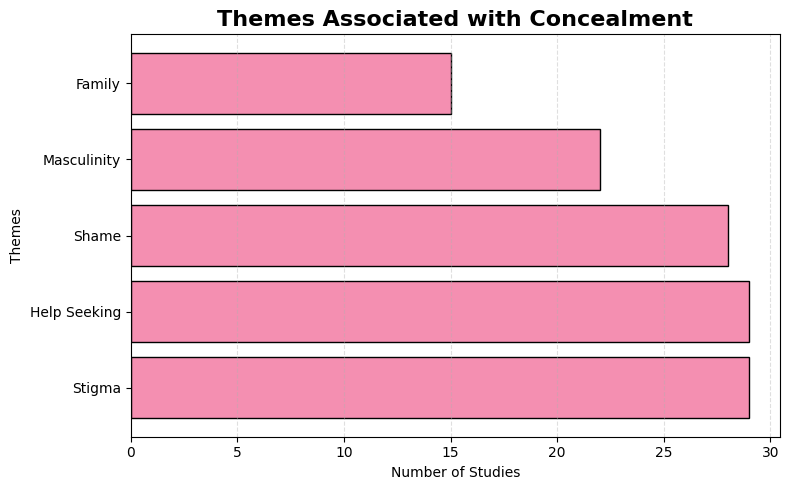

In [25]:
#creating a chart for themes around concealment
import matplotlib.pyplot as plt

themes = ["Stigma", "Help Seeking", "Shame", "Masculinity", "Family"]
counts = [29, 29, 28, 22, 15]

plt.figure(figsize=(8,5))

plt.barh(
    themes,
    counts,
    color="#F48FB1",
    edgecolor="black"
)

plt.title(
    "Themes Associated with Concealment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Studies")
plt.ylabel("Themes")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [26]:
#Performing the NLP PREPROCESSING from here onwards
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter


In [27]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [28]:
#defining and checking for abstracts
abstracts = df["abstract"]
abstracts.head()

,abstract
0,"Historically, male presentations of eating dis..."
1,Background Eating disorders (EDs) are increasi...
2,Background: Eating disorders (EDs) affect indi...
3,Men are believed to be underrepresented in eat...
4,Eating disorders are complex and multifactoria...


In [29]:
text = "".join(abstracts.astype(str))
print(text[:500])

Historically, male presentations of eating disorders (EDs) have been perceived as rare and atypical – a perception that has resulted in the systematic underrepresentation of males in ED research. This underrepresentation has profoundly impacted clinical practice with male patients, in which i) stigmatization and treatment non-engagement are more likely, ii) a distinct array of medical complexities are faced, and iii) symptom presentations differ markedly from female presentations. Further, the m


In [30]:
#cleaning the text
import re

text = text.lower()

text = re.sub(r'[^a-z\s]', ' ', text) #removes punctuation

text = re.sub(r'\s+',' ', text).strip() #removes extra spaces

print(text[:500])

historically male presentations of eating disorders eds have been perceived as rare and atypical a perception that has resulted in the systematic underrepresentation of males in ed research this underrepresentation has profoundly impacted clinical practice with male patients in which i stigmatization and treatment non engagement are more likely ii a distinct array of medical complexities are faced and iii symptom presentations differ markedly from female presentations further the marginalization


In [31]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [32]:
#tokenization

import nltk

from nltk.tokenize import word_tokenize

tokens = word_tokenize(text)

print(tokens[:50])

['historically', 'male', 'presentations', 'of', 'eating', 'disorders', 'eds', 'have', 'been', 'perceived', 'as', 'rare', 'and', 'atypical', 'a', 'perception', 'that', 'has', 'resulted', 'in', 'the', 'systematic', 'underrepresentation', 'of', 'males', 'in', 'ed', 'research', 'this', 'underrepresentation', 'has', 'profoundly', 'impacted', 'clinical', 'practice', 'with', 'male', 'patients', 'in', 'which', 'i', 'stigmatization', 'and', 'treatment', 'non', 'engagement', 'are', 'more', 'likely', 'ii']


In [33]:
#useless words removal
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

filtered_tokens = []

for word in tokens:
    if word not in stop_words:
        filtered_tokens.append(word)

print (filtered_tokens[:50])

['historically', 'male', 'presentations', 'eating', 'disorders', 'eds', 'perceived', 'rare', 'atypical', 'perception', 'resulted', 'systematic', 'underrepresentation', 'males', 'ed', 'research', 'underrepresentation', 'profoundly', 'impacted', 'clinical', 'practice', 'male', 'patients', 'stigmatization', 'treatment', 'non', 'engagement', 'likely', 'ii', 'distinct', 'array', 'medical', 'complexities', 'faced', 'iii', 'symptom', 'presentations', 'differ', 'markedly', 'female', 'presentations', 'marginalization', 'males', 'ed', 'research', 'hindered', 'assessment', 'clinical', 'management', 'presentations']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [34]:
#lemmatization
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

lemmatized_tokens = []

for word in filtered_tokens:
  lemma = lemmatizer.lemmatize(word)
  lemmatized_tokens.append(lemma)

print(lemmatized_tokens[:50])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


['historically', 'male', 'presentation', 'eating', 'disorder', 'ed', 'perceived', 'rare', 'atypical', 'perception', 'resulted', 'systematic', 'underrepresentation', 'male', 'ed', 'research', 'underrepresentation', 'profoundly', 'impacted', 'clinical', 'practice', 'male', 'patient', 'stigmatization', 'treatment', 'non', 'engagement', 'likely', 'ii', 'distinct', 'array', 'medical', 'complexity', 'faced', 'iii', 'symptom', 'presentation', 'differ', 'markedly', 'female', 'presentation', 'marginalization', 'male', 'ed', 'research', 'hindered', 'assessment', 'clinical', 'management', 'presentation']


In [35]:
# remove custom stopwords
custom_stopwords = {
    "study", "studies",
    "result", "results",
    "background",
    "objective", "objectives",
    "method", "methods",
    "conclusion", "conclusions",
    "participant", "participants",
    "paper", "article",
    "research",
    "using", "used",
    "among",
    "ed", "eds"
}

final_tokens = []

for word in lemmatized_tokens:
    if word not in custom_stopwords:
        final_tokens.append(word)

print(final_tokens[:50])

['historically', 'male', 'presentation', 'eating', 'disorder', 'perceived', 'rare', 'atypical', 'perception', 'resulted', 'systematic', 'underrepresentation', 'male', 'underrepresentation', 'profoundly', 'impacted', 'clinical', 'practice', 'male', 'patient', 'stigmatization', 'treatment', 'non', 'engagement', 'likely', 'ii', 'distinct', 'array', 'medical', 'complexity', 'faced', 'iii', 'symptom', 'presentation', 'differ', 'markedly', 'female', 'presentation', 'marginalization', 'male', 'hindered', 'assessment', 'clinical', 'management', 'presentation', 'critical', 'review', 'provides', 'overview', 'history']


In [36]:
from nltk.util import bigrams
from collections import Counter

# Generate bigrams
bigram_list = list(bigrams(final_tokens))

# Count frequencies
bigram_counts = Counter(bigram_list)

print(bigram_counts.most_common(20))

[(('eating', 'disorder'), 170), (('body', 'image'), 45), (('disordered', 'eating'), 41), (('help', 'seeking'), 21), (('muscularity', 'oriented'), 20), (('body', 'dissatisfaction'), 18), (('eating', 'behavior'), 16), (('mental', 'health'), 14), (('anorexia', 'nervosa'), 13), (('boy', 'men'), 12), (('bulimia', 'nervosa'), 12), (('disorder', 'male'), 11), (('nervosa', 'bulimia'), 11), (('risk', 'factor'), 10), (('oriented', 'disordered'), 9), (('body', 'mass'), 9), (('mass', 'index'), 9), (('disorder', 'men'), 9), (('binge', 'eating'), 9), (('university', 'student'), 9)]


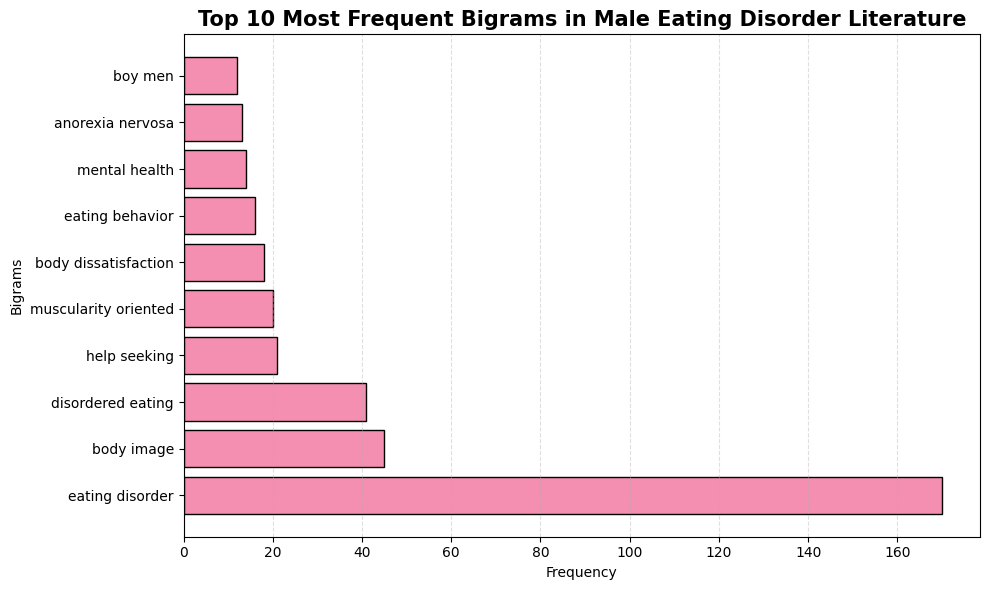

In [37]:
import matplotlib.pyplot as plt

# Top 10 bigrams
top_bigrams = bigram_counts.most_common(10)

labels = []
counts = []

for item in top_bigrams:

    word1 = item[0][0]
    word2 = item[0][1]

    labels.append(word1 + " " + word2)
    counts.append(item[1])

plt.figure(figsize=(10,6))

plt.barh(
    labels,
    counts,
    color="#F48FB1",
    edgecolor="black"
)

plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.title(
    "Top 10 Most Frequent Bigrams in Male Eating Disorder Literature",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [38]:
# Select papers discussing concealment

concealment_df = df[df["Concealment"] == 1]

print(concealment_df.shape)

(30, 21)


In [39]:
# Create corpus from concealment abstracts

concealment_abstracts = concealment_df["abstract"]

concealment_text = " ".join(concealment_abstracts.astype(str))

print(concealment_text[:500])

Historically, male presentations of eating disorders (EDs) have been perceived as rare and atypical – a perception that has resulted in the systematic underrepresentation of males in ED research. This underrepresentation has profoundly impacted clinical practice with male patients, in which i) stigmatization and treatment non-engagement are more likely, ii) a distinct array of medical complexities are faced, and iii) symptom presentations differ markedly from female presentations. Further, the m


In [40]:
#cleaning

import re

concealment_text = concealment_text.lower()

concealment_text = re.sub(r'[^a-z\s]', ' ', concealment_text)

concealment_text = re.sub(r'\s+', ' ', concealment_text).strip()

print(concealment_text[:500])

historically male presentations of eating disorders eds have been perceived as rare and atypical a perception that has resulted in the systematic underrepresentation of males in ed research this underrepresentation has profoundly impacted clinical practice with male patients in which i stigmatization and treatment non engagement are more likely ii a distinct array of medical complexities are faced and iii symptom presentations differ markedly from female presentations further the marginalization


In [41]:
#tokenize
concealment_tokens = word_tokenize(concealment_text)

print(concealment_tokens[:50])

['historically', 'male', 'presentations', 'of', 'eating', 'disorders', 'eds', 'have', 'been', 'perceived', 'as', 'rare', 'and', 'atypical', 'a', 'perception', 'that', 'has', 'resulted', 'in', 'the', 'systematic', 'underrepresentation', 'of', 'males', 'in', 'ed', 'research', 'this', 'underrepresentation', 'has', 'profoundly', 'impacted', 'clinical', 'practice', 'with', 'male', 'patients', 'in', 'which', 'i', 'stigmatization', 'and', 'treatment', 'non', 'engagement', 'are', 'more', 'likely', 'ii']


In [42]:
#remove stopwords
concealment_filtered = []

for word in concealment_tokens:
    if word not in stop_words:
        concealment_filtered.append(word)

print(concealment_filtered[:50])

['historically', 'male', 'presentations', 'eating', 'disorders', 'eds', 'perceived', 'rare', 'atypical', 'perception', 'resulted', 'systematic', 'underrepresentation', 'males', 'ed', 'research', 'underrepresentation', 'profoundly', 'impacted', 'clinical', 'practice', 'male', 'patients', 'stigmatization', 'treatment', 'non', 'engagement', 'likely', 'ii', 'distinct', 'array', 'medical', 'complexities', 'faced', 'iii', 'symptom', 'presentations', 'differ', 'markedly', 'female', 'presentations', 'marginalization', 'males', 'ed', 'research', 'hindered', 'assessment', 'clinical', 'management', 'presentations']


In [43]:
#lemmatize
concealment_lemmas = []

for word in concealment_filtered:
    lemma = lemmatizer.lemmatize(word)
    concealment_lemmas.append(lemma)

print(concealment_lemmas[:50])

['historically', 'male', 'presentation', 'eating', 'disorder', 'ed', 'perceived', 'rare', 'atypical', 'perception', 'resulted', 'systematic', 'underrepresentation', 'male', 'ed', 'research', 'underrepresentation', 'profoundly', 'impacted', 'clinical', 'practice', 'male', 'patient', 'stigmatization', 'treatment', 'non', 'engagement', 'likely', 'ii', 'distinct', 'array', 'medical', 'complexity', 'faced', 'iii', 'symptom', 'presentation', 'differ', 'markedly', 'female', 'presentation', 'marginalization', 'male', 'ed', 'research', 'hindered', 'assessment', 'clinical', 'management', 'presentation']


In [44]:
# Remove custom stopwords

custom_stopwords = {
    "study", "studies",
    "result", "results",
    "background",
    "objective", "objectives",
    "method", "methods",
    "conclusion", "conclusions",
    "participant", "participants",
    "paper", "article",
    "research",
    "using", "used",
    "among",
    "ed", "eds",

    # Domain-specific stopwords
    "eating",
    "disorder",
    "disorders",
    "male",
    "men"
}

concealment_final = []

for word in concealment_lemmas:
    if word not in custom_stopwords:
        concealment_final.append(word)

print(concealment_final[:50])

['historically', 'presentation', 'perceived', 'rare', 'atypical', 'perception', 'resulted', 'systematic', 'underrepresentation', 'underrepresentation', 'profoundly', 'impacted', 'clinical', 'practice', 'patient', 'stigmatization', 'treatment', 'non', 'engagement', 'likely', 'ii', 'distinct', 'array', 'medical', 'complexity', 'faced', 'iii', 'symptom', 'presentation', 'differ', 'markedly', 'female', 'presentation', 'marginalization', 'hindered', 'assessment', 'clinical', 'management', 'presentation', 'critical', 'review', 'provides', 'overview', 'history', 'synthesizes', 'current', 'evidence', 'relating', 'unique', 'characteristic']


In [45]:
#concealment bigrams
from nltk.util import bigrams
from collections import Counter

# Generate bigrams
concealment_bigram_list = list(bigrams(concealment_final))

# Count frequencies
concealment_bigram_counts = Counter(concealment_bigram_list)

print(concealment_bigram_counts.most_common(20))

[(('help', 'seeking'), 21), (('mental', 'health'), 11), (('anorexia', 'nervosa'), 10), (('muscularity', 'oriented'), 9), (('nervosa', 'bulimia'), 9), (('bulimia', 'nervosa'), 9), (('seeking', 'intention'), 8), (('seeking', 'behavior'), 7), (('stigma', 'related'), 7), (('related', 'perception'), 6), (('body', 'image'), 6), (('western', 'country'), 6), (('muscle', 'dysmorphia'), 5), (('gender', 'specific'), 5), (('risk', 'factor'), 5), (('middle', 'eastern'), 5), (('r', 'p'), 5), (('status', 'risk'), 5), (('gender', 'expression'), 5), (('risk', 'experiencing'), 5)]


In [46]:
concealment_bigram_counts.most_common(20)

[(('help', 'seeking'), 21),
 (('mental', 'health'), 11),
 (('anorexia', 'nervosa'), 10),
 (('muscularity', 'oriented'), 9),
 (('nervosa', 'bulimia'), 9),
 (('bulimia', 'nervosa'), 9),
 (('seeking', 'intention'), 8),
 (('seeking', 'behavior'), 7),
 (('stigma', 'related'), 7),
 (('related', 'perception'), 6),
 (('body', 'image'), 6),
 (('western', 'country'), 6),
 (('muscle', 'dysmorphia'), 5),
 (('gender', 'specific'), 5),
 (('risk', 'factor'), 5),
 (('middle', 'eastern'), 5),
 (('r', 'p'), 5),
 (('status', 'risk'), 5),
 (('gender', 'expression'), 5),
 (('risk', 'experiencing'), 5)]

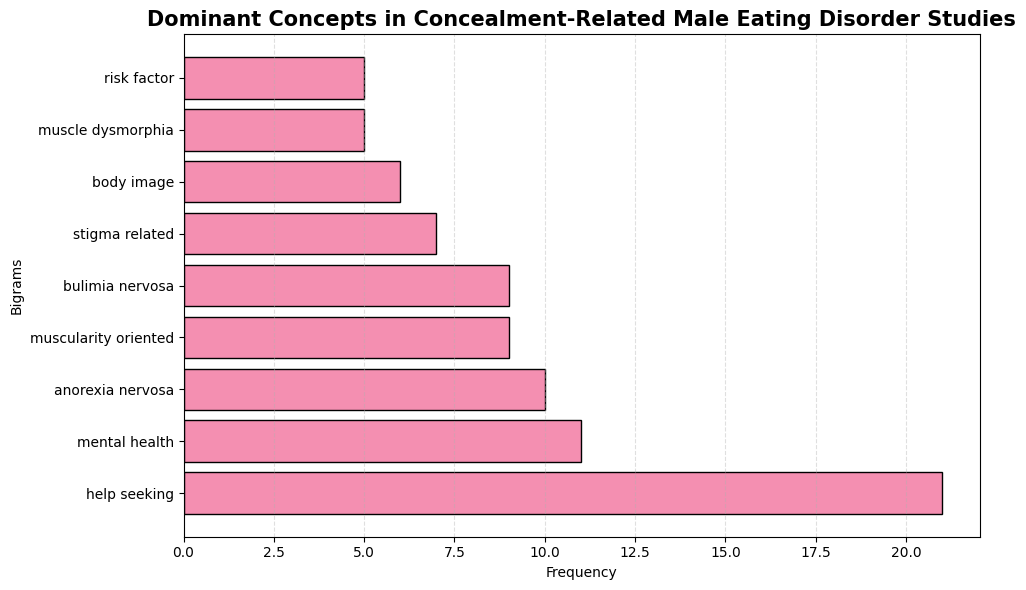

In [47]:
import matplotlib.pyplot as plt

# Select only meaningful bigrams for plotting
selected_bigrams = [
    ("help seeking", 21),
    ("mental health", 11),
    ("anorexia nervosa", 10),
    ("muscularity oriented", 9),
    ("bulimia nervosa", 9),
    ("stigma related", 7),
    ("body image", 6),
    ("muscle dysmorphia", 5),
    ("risk factor", 5)
]

labels = [item[0] for item in selected_bigrams]
counts = [item[1] for item in selected_bigrams]

plt.figure(figsize=(10,6))

plt.barh(
    labels,
    counts,
    color="#F48FB1",
    edgecolor="black"
)

plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.title(
    "Dominant Concepts in Concealment-Related Male Eating Disorder Studies",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [48]:
# Function to display keyword in context

def keyword_context(text, keyword, window=8):

    words = text.split()

    for i, word in enumerate(words):

        if word == keyword:

            start = max(i - window, 0)
            end = min(i + window + 1, len(words))

            print("...", " ".join(words[start:end]), "...\n")

In [49]:
keyword_context(concealment_text, "help")

... e stigma against men with eds could impede help seeking behaviors the present study investigated whether stigma ...

... related perceptions in men are associated with reduced help seeking intentions for a broad range of disordered ...

... stigma related perceptions of eds in men and help seeking intentions results moderator analyses showed that higher ...

... related to thin body ideals but not for help seeking with regard to muscularity oriented orthorexic or ...

... avoidant restrictive disordered eating conclusions stigma may reduce help seeking intentions with regard to feminized ed symptoms ...

... as women s diseases were associated with reduced help seeking in men stigma towards men with eds ...

... eds could thus be a possible barrier to help seeking in men highlighting the relevance of stigma ...

... stigma related to eds in men may impede help seeking particularly for symptoms that deviate from traditional ...

... moderate the association between disordered eating

In [50]:

keyword_context(concealment_text, "stigma")

... persistent stereotypes prejudice and discrimi nation i e stigma against men with eds could impede help seeking ...

... help seeking behaviors the present study investigated whether stigma related perceptions in men are associated with reduced ...

... questionnaires on ed psychopathology muscle dysmorphia orthorexic eating stigma related perceptions of eds in men and help ...

... seeking intentions results moderator analyses showed that higher stigma related perceptions were associated with reduced helpseeking intentions ...

... oriented orthorexic or avoidant restrictive disordered eating conclusions stigma may reduce help seeking intentions with regard to ...

... were associated with reduced help seeking in men stigma towards men with eds could thus be a ...

... help seeking in men highlighting the relevance of stigma reducing interventions in clinical and community settings background ...

... but men remain underrepresented in ed treatment settings stigma related to eds in

In [51]:
keyword_context(concealment_text, "shame")

In [52]:
keyword_context(concealment_text, "family")

... results a diverse range of treatments such as family therapy paediatric psychiatric inpatient care cbt and counselling ...

... to professionals and services culture specific factors include family obligations and promoting family harmony balancing interdependence and ...

... culture specific factors include family obligations and promoting family harmony balancing interdependence and independence from one s ...

... harmony balancing interdependence and independence from one s family as well as understanding family body ideals versus ...

... from one s family as well as understanding family body ideals versus broader societal body ideals are ...

... some themes paralleled other qualitative syntheses highlighting improved family relationships perceived authoritarianism in treatments and financial barriers ...

... beyond the previous findings revealing nuanced factors like family roles cultural values and norms clinical recommendations include ...

... cultural values and norms 

In [53]:
keyword_context(concealment_text, "masculinity")

... how this challenged the men s experiences of masculinity conclusions being a man with an eating disorder ...

... of eds as women s disorders and traditional masculinity norms create gender specific barriers to recognition and ...



In [54]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful